# Main notebook

### Init

In [19]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from src.data.data import load_data, mol_types
from src.utils.plotting import plot_smiles, plot_metals
from src.data.preprocess import keep_largest

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import IPythonConsole

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Init data

In [12]:
path = Path("Data") / "toxicity_fish.csv"
selected_columns = ["SMILES", "conc"]
cut = 200
# cut = None

df = load_data(path, selected_columns, cut)

print(df.head())



       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17


### Data analysis

/Users/elonvginstrup/GNN Thesis/gnn-thesis/src/utils/plotting.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='SMILES', y='Count', palette='viridis')
/Users/elonvginstrup/GNN Thesis/gnn-thesis/src/utils/plotting.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


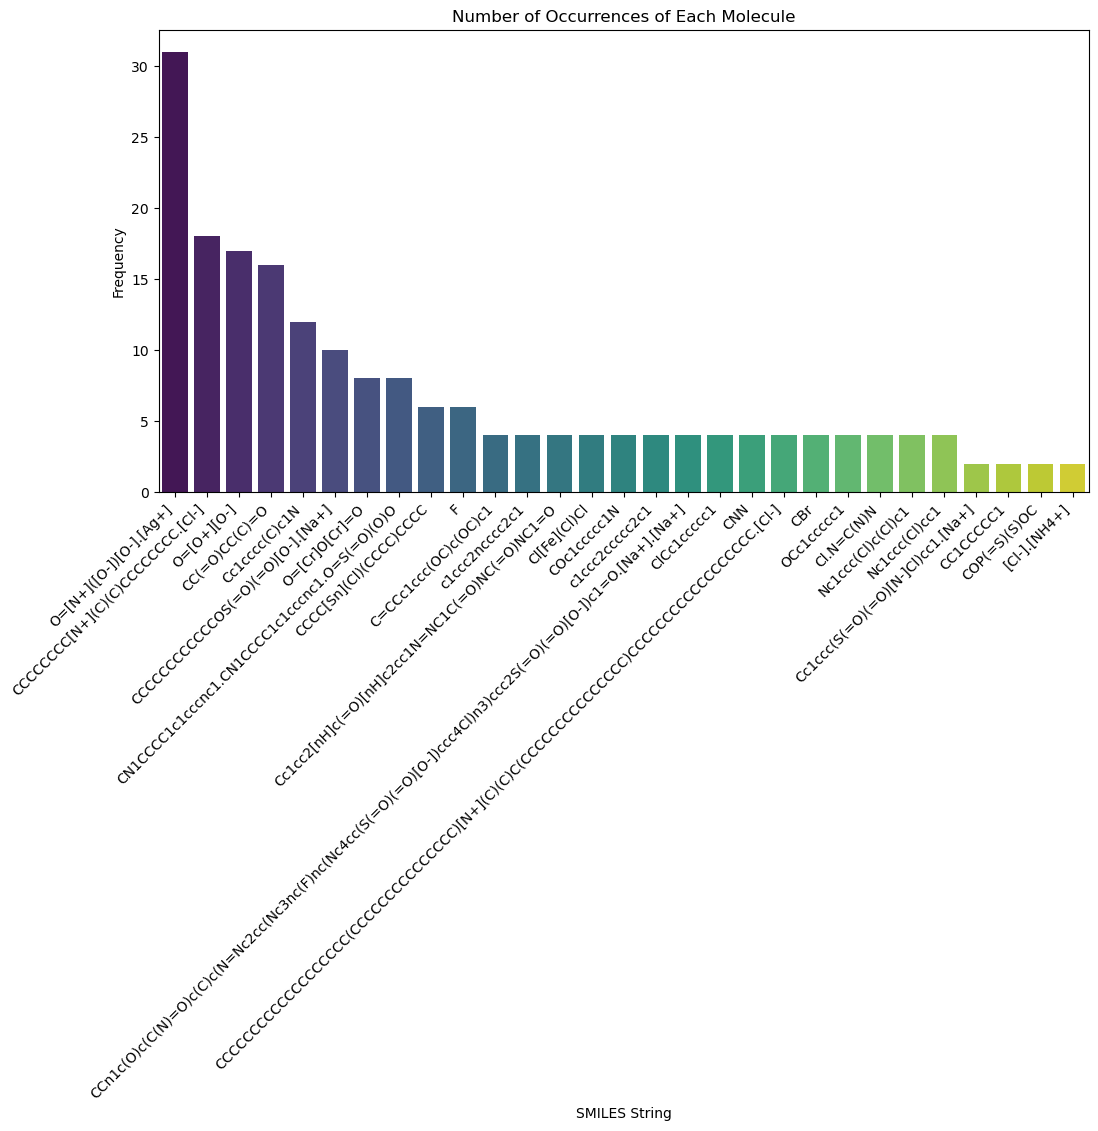

In [14]:
# Unique smiles
plot_smiles(df, figsize=[12, 6])

Total molecules: 200
Unique molecules: 29
Salts: 83, 41.50%
Single atoms: 6, 3.00%
Metals: 34, 17.00%


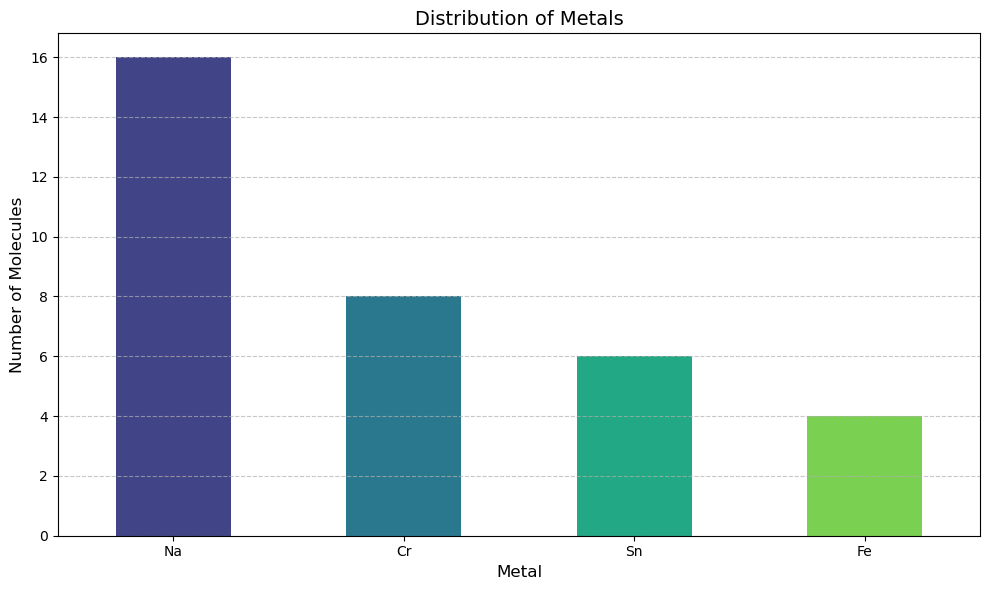

In [8]:
# Mol types and metals

mol_types(df)
plot_metals(df)

### DeepChem

In [9]:
import deepchem as dc

# Convert to deepchem
featurizer = dc.feat.MolGraphConvFeaturizer(use_edges=True)
smiles_dc = featurizer.featurize(df['SMILES'].tolist())

print(type(smiles_dc[0]))

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
/opt/miniconda3/envs/gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading modules with pytorch-geometric dependency, mis

<class 'deepchem.feat.graph_data.GraphData'>
